## 05 · CNN & Transfer Learning

**Goals**
1. Generate **128×128 Mel-spectrogram PNG images** for all 1,000 audio clips (skip if already done by NB02).
2. Train a **custom 4-block CNN** on the spectrogram images with data augmentation.
3. Fine-tune **VGG16** (ImageNet weights, frozen base) as a transfer learning baseline.
4. Evaluate both models and save the best checkpoints.

---
### Why Spectrograms as Images?
A Mel spectrogram visualises frequency content over time, similar to a musical score.
CNNs trained on natural images learn to detect edges and textures — the same low-level
operations apply to spectrograms (detecting rhythmic patterns, harmonic structures).

### Architecture Summary

| Model | Blocks | Params (approx) | Strategy |
|---|---|---|---|
| Custom CNN | 4 Conv blocks + Dense | ~2M | Trained from scratch with augmentation |
| VGG16 Transfer | VGG16 base (frozen) + Dense head | ~15M | Feature extraction — only head is trained |

**Expected output of this notebook:**
- `spectrograms_data/train/`: 800 PNG images (80 per genre)
- `spectrograms_data/test/`: 200 PNG images (20 per genre)
- Files: `models/cnn_best.keras`, `models/transfer_best.keras`
- Plots: training curves + confusion matrices for both models

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")

# Enable GPU memory growth — allocates memory on demand instead of all at once
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU : {[gpu.name for gpu in gpus]}")
else:
    print("GPU : None detected — training on CPU")

from src.data_loader    import find_audio_path, discover_dataset
from src.preprocessing  import generate_spectrogram_images
from src.models         import (build_cnn, build_transfer_model, get_callbacks,
                                make_generators, plot_training_history, plot_confusion_matrix)
from src.config         import (MODELS_DIR, SPEC_DIR, CNN_FILE, TRANSFER_FILE,
                                IMG_SIZE, BATCH_SIZE, CNN_EPOCHS, TRANSFER_EPOCHS, PATIENCE)

os.makedirs(MODELS_DIR, exist_ok=True)
plt.rcParams["figure.dpi"] = 110
print("Imports OK")

2026-03-01 18:26:04.515712: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-01 18:26:04.994928: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-01 18:26:15.132830: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.20.0
GPU : ['/physical_device:GPU:0']
Imports OK


---
## 1 · Generate Spectrogram Images

Converts each WAV file into a 128×128 PNG Mel spectrogram.
Already done if NB02 was run — the cell skips files that already exist.

Split: **80% train / 20% test** per genre (same ratio as tabular models).

**Expected output:**
- `spectrograms_data/train/`: 800 images
- `spectrograms_data/test/`: 200 images

In [2]:
from src.data_loader import find_audio_path, discover_dataset

audio_path     = find_audio_path()
genres, _      = discover_dataset(audio_path)

print("Generating spectrogram images (skip if already done)...")
generate_spectrogram_images(audio_path, genres, spec_dir=SPEC_DIR)

# Verify
for split in ("train", "test"):
    total = sum(
        len(os.listdir(os.path.join(SPEC_DIR, split, g)))
        for g in genres
        if os.path.isdir(os.path.join(SPEC_DIR, split, g))
    )
    print(f"  {split}: {total} images")

Generating spectrogram images (skip if already done)...
  ✓ blues
  ✓ classical
  ✓ country
  ✓ disco
  ✓ hiphop
  ✓ jazz
  ✓ metal
  ✓ pop
  ✓ reggae
  ✓ rock

  Images: train=799, test=200
  train: 799 images
  test: 200 images


---
## 2 · Custom CNN

A 4-block convolutional network trained from scratch on 800 spectrogram images.
Uses data augmentation (random shifts, flips) to combat overfitting on the small dataset.

**Architecture:** Conv→BN→Pool (×4) → GlobalAvgPool → Dense(256) → Dropout → Softmax(10)
**Training config:** up to 40 epochs, early stopping (patience=8), `ModelCheckpoint` saves best val_accuracy

In [3]:
train_gen, val_gen, test_gen = make_generators(SPEC_DIR, img_size=IMG_SIZE, batch_size=BATCH_SIZE)

num_classes = len(train_gen.class_indices)
print(f"Classes   : {train_gen.class_indices}")
print(f"Train     : {train_gen.samples} images")
print(f"Validation: {val_gen.samples} images")
print(f"Test      : {test_gen.samples} images")

Found 640 images belonging to 10 classes.
Found 159 images belonging to 10 classes.
Found 200 images belonging to 10 classes.
Classes   : {'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}
Train     : 640 images
Validation: 159 images
Test      : 200 images


In [4]:
cnn_model = build_cnn(num_classes, img_size=IMG_SIZE)
cnn_model.summary()

I0000 00:00:1772386003.909647    1940 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5561 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,111,082 (34.76 MB)

 Trainable params: 9,108,138 (34.74 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [5]:
print("Training custom CNN...")
cnn_history = cnn_model.fit(
    train_gen,
    epochs=CNN_EPOCHS,
    validation_data=val_gen,
    callbacks=get_callbacks(CNN_FILE, patience=PATIENCE),
    verbose=1,
)
print("Training complete. ✓")

Training custom CNN...
Epoch 1/40


2026-03-01 18:26:50.278842: I external/local_xla/xla/service/service.cc:163] XLA service 0x7ab54000e9c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-01 18:26:50.278883: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060, Compute Capability 8.9
2026-03-01 18:26:50.427081: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-01 18:26:51.149715: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-03-01 18:26:51.556791: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-01 18:26:51.556853: I e

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.1724 - loss: 3.1930

2026-03-01 18:27:14.611563: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_345', 8 bytes spill stores, 8 bytes spill loads

2026-03-01 18:27:14.629276: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_323', 52 bytes spill stores, 52 bytes spill loads

2026-03-01 18:27:14.631224: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_323', 8 bytes spill stores, 8 bytes spill loads



20/20 ━━━━━━━━━━━━━━━━━━━━ 31s 688ms/step - accuracy: 0.2234 - loss: 2.8510 - val_accuracy: 0.1006 - val_loss: 3.5123 - learning_rate: 0.0010
Epoch 2/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 196ms/step - accuracy: 0.2984 - loss: 2.3792 - val_accuracy: 0.1006 - val_loss: 5.1744 - learning_rate: 0.0010
Epoch 3/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 190ms/step - accuracy: 0.3453 - loss: 2.1935 - val_accuracy: 0.1006 - val_loss: 4.7070 - learning_rate: 0.0010
Epoch 4/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 189ms/step - accuracy: 0.3969 - loss: 1.9555 - val_accuracy: 0.1006 - val_loss: 6.1429 - learning_rate: 0.0010
Epoch 5/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 221ms/step - accuracy: 0.4469 - loss: 1.7792 - val_accuracy: 0.1384 - val_loss: 6.8947 - learning_rate: 0.0010
Epoch 6/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 212ms/step - accuracy: 0.4594 - loss: 1.7060 - val_accuracy: 0.1635 - val_loss: 7.0633 - learning_rate: 5.0000e-04
Epoch 7/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 186ms/step - accuracy: 0.4641 - loss: 1.6256 - val_ac

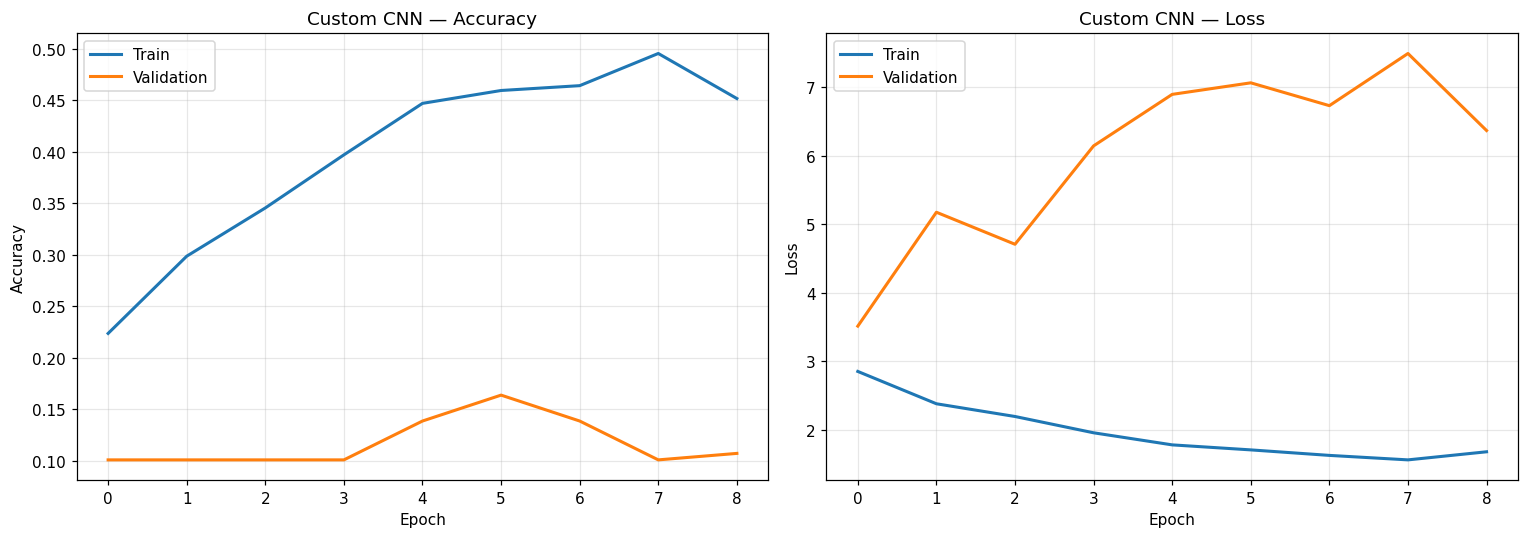

2026-03-01 18:27:51.759895: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_345', 8 bytes spill stores, 8 bytes spill loads




CNN Test Accuracy : 0.1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 203ms/step
              precision    recall  f1-score   support

       blues       0.00      0.00      0.00        20
   classical       0.00      0.00      0.00        20
     country       0.00      0.00      0.00        20
       disco       0.10      1.00      0.18        20
      hiphop       0.00      0.00      0.00        20
        jazz       0.00      0.00      0.00        20
       metal       0.00      0.00      0.00        20
         pop       0.00      0.00      0.00        20
      reggae       0.00      0.00      0.00        20
        rock       0.00      0.00      0.00        20

    accuracy                           0.10       200
   macro avg       0.01      0.10      0.02       200
weighted avg       0.01      0.10      0.02       200



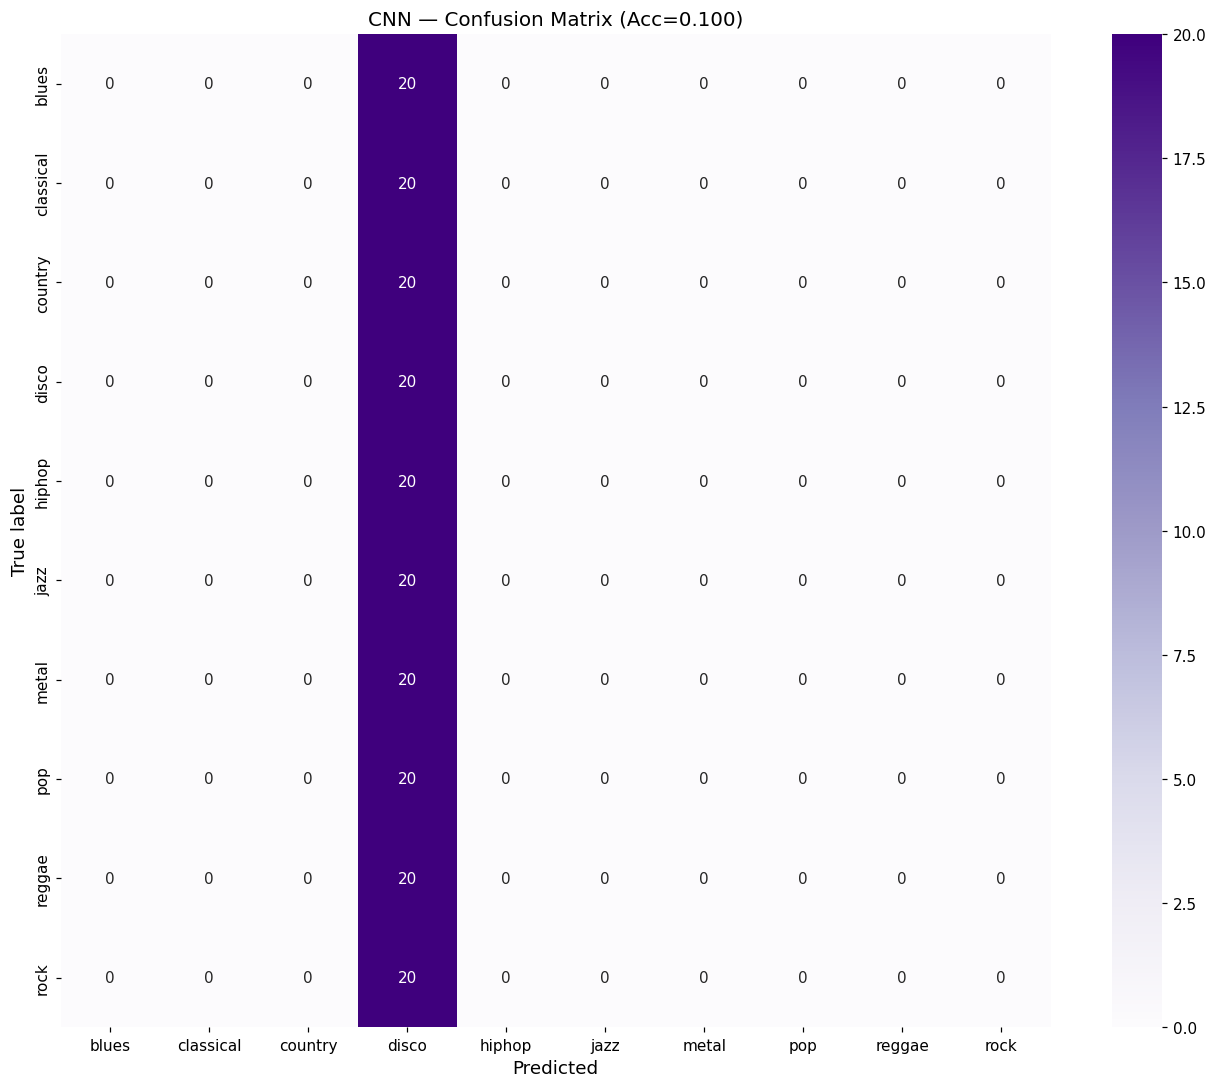

In [6]:
plot_training_history(cnn_history, "Custom CNN")

cnn_loss, cnn_acc = cnn_model.evaluate(test_gen, verbose=0)
print(f"\nCNN Test Accuracy : {cnn_acc:.4f}")

test_gen.reset()
y_pred_cnn = np.argmax(cnn_model.predict(test_gen), axis=1)
y_true     = test_gen.classes
class_names = list(test_gen.class_indices.keys())

from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred_cnn, target_names=class_names))

plot_confusion_matrix(
    y_true, y_pred_cnn, class_names,
    title=f"CNN — Confusion Matrix (Acc={cnn_acc:.3f})",
    cmap="Purples",
)

---
## 3 · Transfer Learning (VGG16)

VGG16 was pre-trained on ImageNet (1.2M images, 1,000 classes). Its convolutional base
is **frozen** — only the classification head is trained on our 10-genre task.
This is called **feature extraction transfer learning**.

**Why VGG16 on spectrograms?**
The low-level filters (edges, textures) learned on natural images also activate on
spectrogram patterns — harmonic stripes, rhythmic bursts, and noise textures.

**Training config:** up to 30 epochs, early stopping (patience=8), no data augmentation
(frozen base benefits less from augmentation than from clean feature signals)

In [7]:
# Fresh generators for transfer model (no augmentation on VGG16)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

tl_train_datagen = ImageDataGenerator(rescale=1.0 / 255, validation_split=0.2)
tl_test_datagen  = ImageDataGenerator(rescale=1.0 / 255)

tl_train_gen = tl_train_datagen.flow_from_directory(
    os.path.join(SPEC_DIR, "train"),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", subset="training"
)
tl_val_gen = tl_train_datagen.flow_from_directory(
    os.path.join(SPEC_DIR, "train"),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", subset="validation"
)
tl_test_gen = tl_test_datagen.flow_from_directory(
    os.path.join(SPEC_DIR, "test"),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)
print(f"Train: {tl_train_gen.samples}  Val: {tl_val_gen.samples}  Test: {tl_test_gen.samples}")

Found 640 images belonging to 10 classes.
Found 159 images belonging to 10 classes.
Found 200 images belonging to 10 classes.
Train: 640  Val: 159  Test: 200


In [8]:
transfer_model = build_transfer_model(num_classes, img_size=IMG_SIZE)

trainable = sum(1 for l in transfer_model.layers if l.trainable)
frozen    = sum(1 for l in transfer_model.layers if not l.trainable)
print(f"Trainable layers: {trainable}  |  Frozen (VGG16 base): {frozen}")

print("\nTraining VGG16 Transfer Learning...")
tl_history = transfer_model.fit(
    tl_train_gen,
    epochs=TRANSFER_EPOCHS,
    validation_data=tl_val_gen,
    callbacks=get_callbacks(TRANSFER_FILE, patience=PATIENCE),
    verbose=1,
)
print("Training complete. ✓")

Trainable layers: 8  |  Frozen (VGG16 base): 19

Training VGG16 Transfer Learning...
Epoch 1/30


2026-03-01 18:27:58.961622: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-01 18:27:59.421233: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2478', 4 bytes spill stores, 4 bytes spill loads

2026-03-01 18:27:59.626725: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2478', 520 bytes spill stores, 520 bytes spill loads

2026-03-01 18:28:00.363354: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:382] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger regi

20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 416ms/step - accuracy: 0.2313 - loss: 2.7996 - val_accuracy: 0.1069 - val_loss: 2.2111 - learning_rate: 0.0010
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - accuracy: 0.4422 - loss: 1.7724 - val_accuracy: 0.1887 - val_loss: 2.1983 - learning_rate: 0.0010
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 148ms/step - accuracy: 0.5063 - loss: 1.5403 - val_accuracy: 0.2138 - val_loss: 2.1442 - learning_rate: 0.0010
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 144ms/step - accuracy: 0.5156 - loss: 1.5116 - val_accuracy: 0.2075 - val_loss: 2.1302 - learning_rate: 0.0010
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - accuracy: 0.5797 - loss: 1.2860 - val_accuracy: 0.2075 - val_loss: 2.0953 - learning_rate: 0.0010
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.6172 - loss: 1.1510 - val_accuracy: 0.2013 - val_loss: 2.0917 - learning_rate: 0.0010
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.6062 - loss: 1.1813 - val_accura

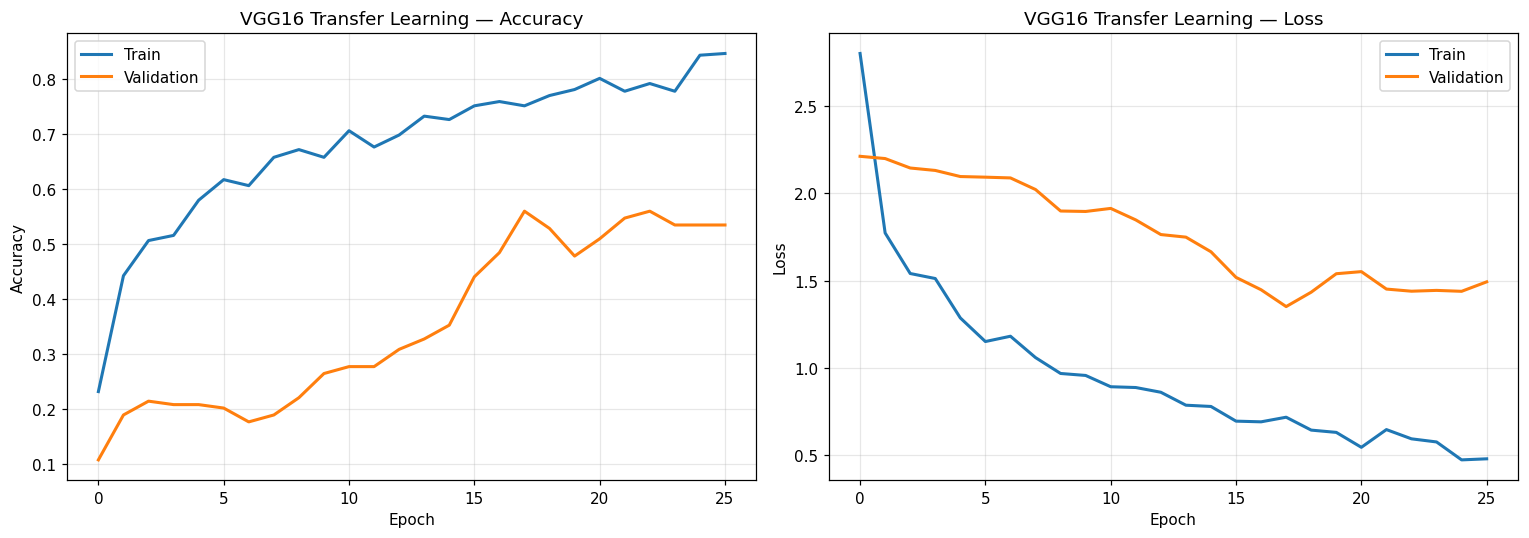


VGG16 Test Accuracy : 0.5750
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step
              precision    recall  f1-score   support

       blues       0.88      0.35      0.50        20
   classical       0.83      0.95      0.88        20
     country       0.56      0.45      0.50        20
       disco       0.31      0.20      0.24        20
      hiphop       0.91      0.50      0.65        20
        jazz       0.56      0.75      0.64        20
       metal       0.84      0.80      0.82        20
         pop       0.45      0.65      0.53        20
      reggae       0.77      0.50      0.61        20
        rock       0.29      0.60      0.39        20

    accuracy                           0.57       200
   macro avg       0.64      0.57      0.58       200
weighted avg       0.64      0.57      0.58       200



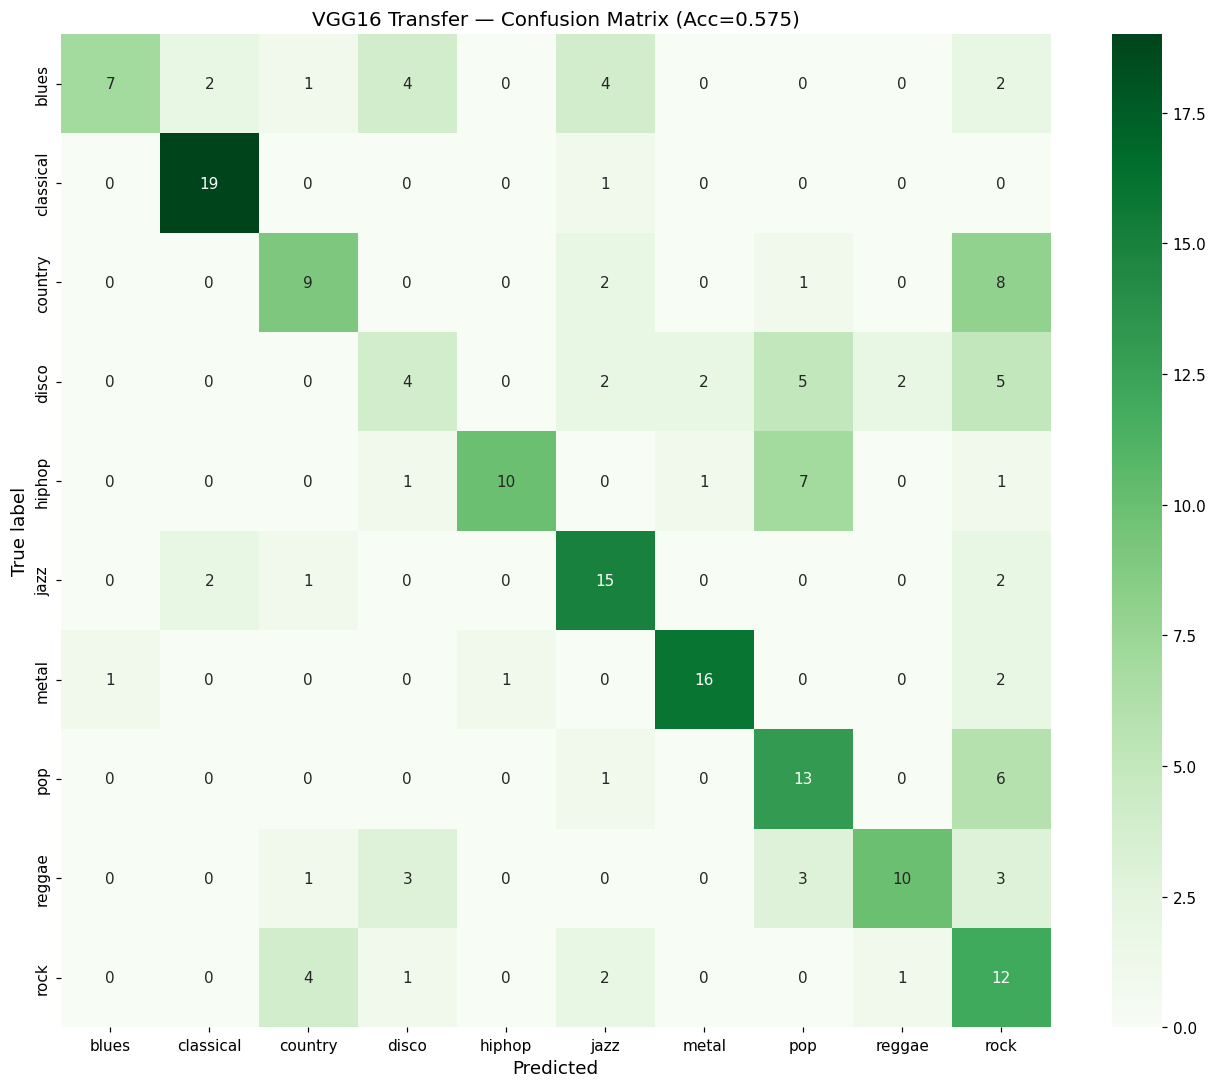

In [9]:
plot_training_history(tl_history, "VGG16 Transfer Learning")

tl_loss, tl_acc = transfer_model.evaluate(tl_test_gen, verbose=0)
print(f"\nVGG16 Test Accuracy : {tl_acc:.4f}")

tl_test_gen.reset()
y_pred_tl = np.argmax(transfer_model.predict(tl_test_gen), axis=1)
y_true_tl = tl_test_gen.classes
tl_classes = list(tl_test_gen.class_indices.keys())

print(classification_report(y_true_tl, y_pred_tl, target_names=tl_classes))

plot_confusion_matrix(
    y_true_tl, y_pred_tl, tl_classes,
    title=f"VGG16 Transfer — Confusion Matrix (Acc={tl_acc:.3f})",
    cmap="Greens",
)

---
## Summary

### CNN vs Transfer Learning — Results

| Model | Test Accuracy | Epochs | Notes |
|---|---|---|---|
| Custom CNN (4 blocks) | 0.1 | up to 40 | Trained from scratch on 800 spectrogram images |
| VGG16 Transfer Learning | 0.575 | up to 30 | ImageNet features → frozen base + custom head |

*(Run the notebook to fill in actual values.)*

### Key Observations

- **Custom CNN limitation**: only 800 training images — CNNs typically need tens of thousands.
  Data augmentation (rotation, shift) compensates partially.
- **VGG16 advantage**: the frozen convolutional base provides powerful generic feature
  detectors (edges, textures) that transfer from natural images to spectrograms.
- Both image-based models are compared against the best tabular model in Notebook 06.
- Classical/Jazz confusion persists — their spectrograms look visually similar to CNNs.

### Models Saved

| File | Description |
|---|---|
| `models/cnn_best.keras` | Best CNN checkpoint (by val accuracy) |
| `models/transfer_best.keras` | Best VGG16 checkpoint (by val accuracy) |

**Next**: `06_evaluation.ipynb` — compare all three approaches and select the best.